In [11]:
# Instalando as bibliotecas necessárias
%pip install pandas matplotlib seaborn numpy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
# Carregando o dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
# Verificando informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
# Verificando valores duplicados (parte ETL)
df.duplicated().sum()

np.int64(0)

In [16]:
# Convertendo as colunas de data para o tipo datetime (possibilitando análises temporais)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [18]:
# Verificando inconsistências de datas (Ship Date < Order Date)
inconsistentes = df[df["Ship Date"] < df["Order Date"]]
inconsistentes.shape[0]

0

In [20]:
# Verificando valores negativos e inconsistentes
print("Sales negativo:", (df["Sales"] < 0).sum())
print("Quantity negativo:", (df["Quantity"] < 0).sum())
print("Discount negativo:", (df["Discount"] < 0).sum())
print("Discount > 1:", (df["Discount"] > 1).sum())

Sales negativo: 0
Quantity negativo: 0
Discount negativo: 0
Discount > 1: 0


In [22]:
# Criando novas colunas para análise
df["Margem"] = df["Profit"] / df["Sales"]
df["Tempo_Envio_Dias"] = (df["Ship Date"] - df["Order Date"]).dt.days
df[["Sales", "Profit", "Margem", "Order Date", "Ship Date", "Tempo_Envio_Dias"]].head()

,Sales,Profit,Margem,Order Date,Ship Date,Tempo_Envio_Dias
0,261.9600,41.9136,0.1600,2016-11-08,2016-11-11,3
1,731.9400,219.5820,0.3000,2016-11-08,2016-11-11,3
2,14.6200,6.8714,0.4700,2016-06-12,2016-06-16,4
3,957.5775,-383.0310,-0.4000,2015-10-11,2015-10-18,7
4,22.3680,2.5164,0.1125,2015-10-11,2015-10-18,7


In [24]:
# Análise exploratória: Resumo por segmento
segmento_resumo = df.groupby("Segment").agg(
    Total_Vendas=("Sales", "sum"),
    Total_Lucro=("Profit", "sum"),
    Qtd_Pedidos=("Order ID", "nunique")
).sort_values("Total_Vendas", ascending=False)

segmento_resumo

,Total_Vendas,Total_Lucro,Qtd_Pedidos
Segment,,,
Consumer,1.161401e+06,134119.2092,2586
Corporate,7.061464e+05,91979.1340,1514
Home Office,4.296531e+05,60298.6785,909


In [26]:
# Calculando a margem real de lucro por segmento
segmento_resumo["Margem_Real"] = segmento_resumo["Total_Lucro"] / segmento_resumo["Total_Vendas"]
segmento_resumo

,Total_Vendas,Total_Lucro,Qtd_Pedidos,Margem_Real
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,0.115481
Corporate,7.061464e+05,91979.1340,1514,0.130255
Home Office,4.296531e+05,60298.6785,909,0.140343


In [27]:
categoria_resumo = df.groupby(["Category", "Sub-Category"]).agg(
    Total_Vendas=("Sales", "sum"),
    Total_Lucro=("Profit", "sum"),
    Desconto_Medio=("Discount", "mean")
).reset_index()

categoria_resumo["Margem_Real"] = categoria_resumo["Total_Lucro"] / categoria_resumo["Total_Vendas"]
categoria_resumo.sort_values("Total_Vendas", ascending=False)

,Category,Sub-Category,Total_Vendas,Total_Lucro,Desconto_Medio,Margem_Real
16,Technology,Phones,330007.0540,44515.7306,0.154556,0.134893
1,Furniture,Chairs,328449.1030,26590.1663,0.170178,0.080957
11,Office Supplies,Storage,223843.6080,21278.8264,0.074704,0.095061
3,Furniture,Tables,206965.5320,-17725.4811,0.261285,-0.085645
6,Office Supplies,Binders,203412.7330,30221.7633,0.372292,0.148574
15,Technology,Machines,189238.6310,3384.7569,0.306087,0.017886
13,Technology,Accessories,167380.3180,41936.6357,0.078452,0.250547
14,Technology,Copiers,149528.0300,55617.8249,0.161765,0.371956
0,Furniture,Bookcases,114879.9963,-3472.5560,0.211140,-0.030228
4,Office Supplies,Appliances,107532.1610,18138.0054,0.166524,0.168675


In [29]:
# Analisando a margem de lucro de produtos com e sem desconto
tables = df[df["Sub-Category"] == "Tables"]

com_desconto = tables[tables["Discount"] > 0]
sem_desconto = tables[tables["Discount"] == 0]

print("Margem média COM desconto:", com_desconto["Profit"].sum() / com_desconto["Sales"].sum())
print("Margem média SEM desconto:", sem_desconto["Profit"].sum() / sem_desconto["Sales"].sum())

Margem média COM desconto: -0.22898677870833645
Margem média SEM desconto: 0.1854782019135285


In [31]:
# Analisando a margem de lucro de produtos com e sem desconto (para as categorias problemáticas)
problematicas = ["Tables", "Bookcases", "Supplies"]

df_prob = df[df["Sub-Category"].isin(problematicas)]
df_prob["Teve_Desconto"] = df_prob["Discount"] > 0

margem_desconto = df_prob.groupby(["Sub-Category", "Teve_Desconto"]).agg(
    Total_Vendas=("Sales", "sum"),
    Total_Lucro=("Profit", "sum")
).reset_index()

margem_desconto["Margem_Real"] = margem_desconto["Total_Lucro"] / margem_desconto["Total_Vendas"]

margem_desconto.sort_values(["Sub-Category", "Teve_Desconto"])

/var/folders/d5/xmxr8d2x15ngd_z632tqm59m0000gn/T/ipykernel_2980/1250246177.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob["Teve_Desconto"] = df_prob["Discount"] > 0


,Sub-Category,Teve_Desconto,Total_Vendas,Total_Lucro,Margem_Real
0,Bookcases,False,31935.9800,6075.7117,0.190247
1,Bookcases,True,82944.0163,-9548.2677,-0.115117
2,Supplies,False,31559.2100,1718.3942,0.054450
3,Supplies,True,15114.3280,-2907.4937,-0.192367
4,Tables,False,71578.7600,13276.2997,0.185478
5,Tables,True,135386.7720,-31001.7808,-0.228987


In [33]:
# Análise exploratória: Resumo por região
regiao_resumo = df.groupby("Region").agg(
    Total_Vendas=("Sales", "sum"),
    Total_Lucro=("Profit", "sum"),
    Qtd_Pedidos=("Order ID", "nunique")
).reset_index()

regiao_resumo["Margem_Real"] = regiao_resumo["Total_Lucro"] / regiao_resumo["Total_Vendas"]

regiao_resumo.sort_values("Total_Vendas", ascending=False)

,Region,Total_Vendas,Total_Lucro,Qtd_Pedidos,Margem_Real
3,West,725457.8245,108418.4489,1611,0.149448
1,East,678781.2400,91522.7800,1401,0.134834
0,Central,501239.8908,39706.3625,1175,0.079216
2,South,391721.9050,46749.4303,822,0.119343


In [35]:
# Calculando a margem real de lucro por região e o desconto médio
regiao_desconto = df.groupby("Region").agg(
    Desconto_Medio=("Discount", "mean"),
    Margem_Real=("Profit", "sum")
)
regiao_desconto["Total_Vendas"] = df.groupby("Region")["Sales"].sum()
regiao_desconto["Margem_Real"] = regiao_desconto["Margem_Real"] / regiao_desconto["Total_Vendas"]

regiao_desconto.sort_values("Margem_Real")

,Desconto_Medio,Margem_Real,Total_Vendas
Region,,,
Central,0.240353,0.079216,501239.8908
South,0.147253,0.119343,391721.9050
East,0.145365,0.134834,678781.2400
West,0.109335,0.149448,725457.8245


In [37]:
# Visualização de dados
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

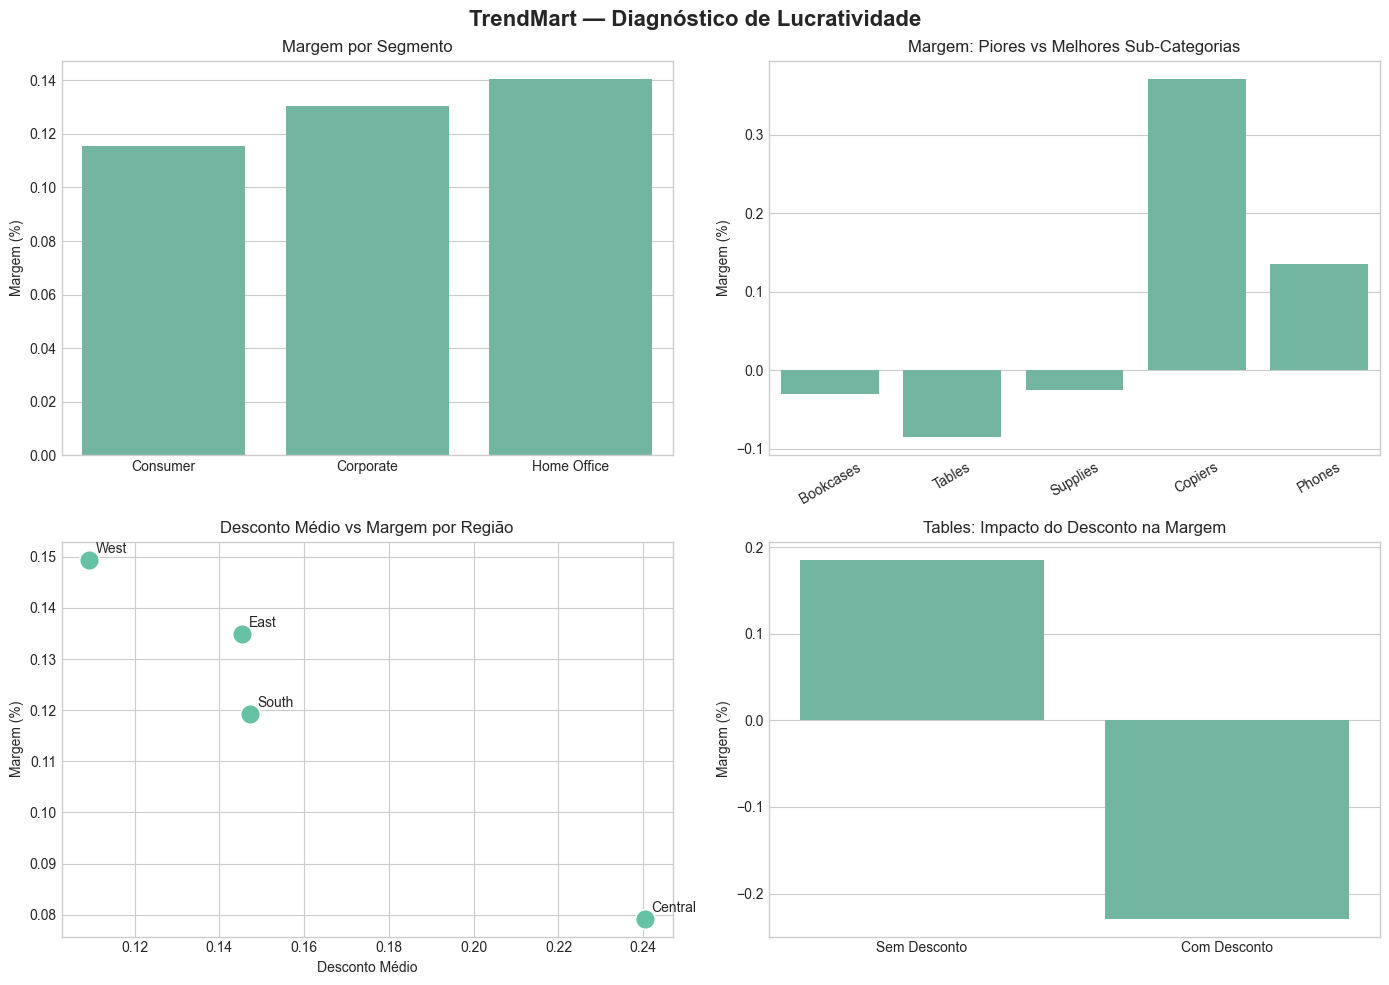

In [39]:
# Criando o dashboard com os gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("TrendMart — Diagnóstico de Lucratividade", fontsize=16, fontweight="bold")

# Gráfico 1: Margem por Segmento
sns.barplot(data=segmento_resumo.reset_index(), x="Segment", y="Margem_Real", ax=axes[0,0])
axes[0,0].set_title("Margem por Segmento")
axes[0,0].set_ylabel("Margem (%)")
axes[0,0].set_xlabel("")

# Gráfico 2: Vendas vs Lucro por Sub-Categoria (só as problemáticas)
sub_plot = categoria_resumo[categoria_resumo["Sub-Category"].isin(["Tables", "Bookcases", "Supplies", "Copiers", "Phones"])]
sns.barplot(data=sub_plot, x="Sub-Category", y="Margem_Real", ax=axes[0,1])
axes[0,1].set_title("Margem: Piores vs Melhores Sub-Categorias")
axes[0,1].set_ylabel("Margem (%)")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis='x', rotation=30)

# Gráfico 3: Desconto médio x Margem por Região
sns.scatterplot(data=regiao_desconto.reset_index(), x="Desconto_Medio", y="Margem_Real", s=200, ax=axes[1,0])
for i, row in regiao_desconto.reset_index().iterrows():
    axes[1,0].annotate(row["Region"], (row["Desconto_Medio"], row["Margem_Real"]), xytext=(5,5), textcoords="offset points")
axes[1,0].set_title("Desconto Médio vs Margem por Região")
axes[1,0].set_xlabel("Desconto Médio")
axes[1,0].set_ylabel("Margem (%)")

# Gráfico 4: Tables com vs sem desconto
tables_comp = margem_desconto[margem_desconto["Sub-Category"] == "Tables"].copy()
tables_comp["Teve_Desconto"] = tables_comp["Teve_Desconto"].map({True: "Com Desconto", False: "Sem Desconto"})
sns.barplot(data=tables_comp, x="Teve_Desconto", y="Margem_Real", ax=axes[1,1])
axes[1,1].set_title("Tables: Impacto do Desconto na Margem")
axes[1,1].set_ylabel("Margem (%)")
axes[1,1].set_xlabel("")

plt.tight_layout()
plt.savefig("dashboard_trendmart.png", dpi=150, bbox_inches="tight")
plt.show()